In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,roc_curve

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [ ]:
df=pd.read_csv('/content/dataset.csv')
df.head()



,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
#Audit
audit_report=pd.DataFrame({
    "datatypes":df.dtypes,
    "missing":df.isnull,
    "missing_pct": round(df.isnull().mean()*100,2),
    "unique":df.nunique(),
    "duplicates":df.duplicated().sum(),

})
display(audit_report)

,datatypes,missing,missing_pct,unique,duplicates
State,object,<bound method DataFrame.isnull of State ...,0.0,51,0
Account length,int64,<bound method DataFrame.isnull of State ...,0.0,212,0
Area code,int64,<bound method DataFrame.isnull of State ...,0.0,3,0
International plan,object,<bound method DataFrame.isnull of State ...,0.0,2,0
Voice mail plan,object,<bound method DataFrame.isnull of State ...,0.0,2,0
Number vmail messages,int64,<bound method DataFrame.isnull of State ...,0.0,46,0
Total day minutes,float64,<bound method DataFrame.isnull of State ...,0.0,1667,0
Total day calls,int64,<bound method DataFrame.isnull of State ...,0.0,119,0
Total day charge,float64,<bound method DataFrame.isnull of State ...,0.0,1667,0
Total eve minutes,float64,<bound method DataFrame.isnull of State ...,0.0,1611,0


In [ ]:
import pandas as pd

# Data Dictionary
data_dictionary = {
    "Account length": "Number of days customer has been associated with the telecom company",
    "State": "Customer's state/location",
    "Area code": "Customer's telecom area code",
    "International plan": "Whether customer has subscribed to international calling plan (Yes/No)",
    "Voice mail plan": "Whether customer has subscribed to voicemail service (Yes/No)",
    "Number vmail messages": "Total number of voicemail messages",
    "Total day minutes": "Total daytime call minutes used by customer",
    "Total day calls": "Total number of daytime calls",
    "Total day charge": "Charges incurred during daytime usage",
    "Total eve minutes": "Total evening call minutes used by customer",
    "Total eve calls": "Total number of evening calls",
    "Total eve charge": "Charges incurred during evening usage",
    "Total night minutes": "Total nighttime call minutes used by customer",
    "Total night calls": "Total number of nighttime calls",
    "Total night charge": "Charges incurred during nighttime usage",
    "Total intl minutes": "Total international call minutes used",
    "Total intl calls": "Total number of international calls",
    "Total intl charge": "Charges incurred from international calls",
    "Customer service calls": "Number of calls made to customer support",
    "Churn": "Target variable indicating whether customer left the company (True/False)"
}

# Convert dictionary to DataFrame
data_dict_df = pd.DataFrame(
    list(data_dictionary.items()),
    columns=["Column Name", "Business Meaning"]
)

# Display DataFrame
print(data_dict_df)

               Column Name                                   Business Meaning
0           Account length  Number of days customer has been associated wi...
1                    State                          Customer's state/location
2                Area code                       Customer's telecom area code
3       International plan  Whether customer has subscribed to internation...
4          Voice mail plan  Whether customer has subscribed to voicemail s...
5    Number vmail messages                 Total number of voicemail messages
6        Total day minutes        Total daytime call minutes used by customer
7          Total day calls                      Total number of daytime calls
8         Total day charge              Charges incurred during daytime usage
9        Total eve minutes        Total evening call minutes used by customer
10         Total eve calls                      Total number of evening calls
11        Total eve charge              Charges incurred during 

In [ ]:
#Bussiness KPI Layaer
# Calculate Total Charges
df["Total charges"] = (
    df["Total day charge"] +
    df["Total eve charge"] +
    df["Total night charge"] +
    df["Total intl charge"]
)

# Average Revenue Per Customer (ARPC)
avg_revenue_per_customer = df["Total charges"].mean()

# Estimated Annual Customer Lifetime Value (CLV)
clv = avg_revenue_per_customer * 12

# Churn Rate
print(f"Churn Rate: {df['Churn'].mean() * 100:.2f}%")

# Average Revenue Per Customer
print(f"Average Revenue Per Customer: Rs. {avg_revenue_per_customer:.2f}")

# Estimated Annual CLV
print(f"Estimated Annual CLV: Rs. {clv:.2f}")

Churn Rate: 14.49%
Average Revenue Per Customer: Rs. 59.45
Estimated Annual CLV: Rs. 713.40


In [ ]:
# KPI Summary DataFrame
kpis = pd.DataFrame({
    "Metric": [
        "Customers",
        "Churn %",
        "Avg Revenue",
        "Annual CLV"
    ],
    "Value": [
        len(df),
        round(df["Churn"].mean() * 100, 2),
        round(df["Total charges"].mean(), 2),
        round(clv, 2)
    ]
})

display(kpis)

,Metric,Value
0,Customers,3333.00
1,Churn %,14.49
2,Avg Revenue,59.45
3,Annual CLV,713.40


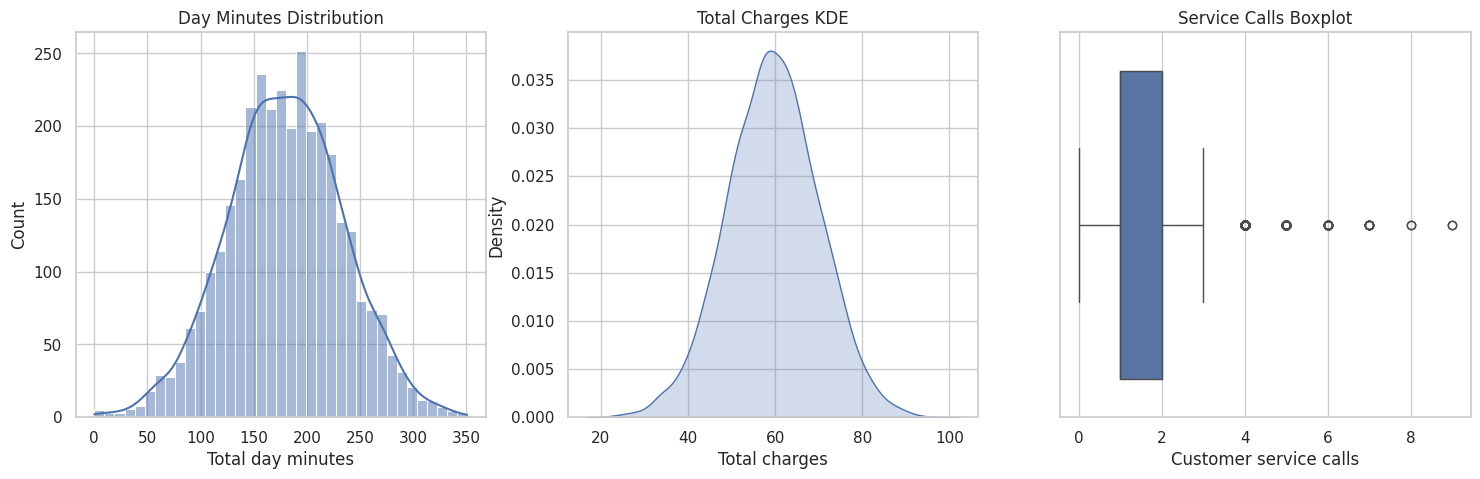

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Total day minutes'], kde=True, ax=ax[0])
ax[0].set_title('Day Minutes Distribution')

sns.kdeplot(df['Total charges'], fill=True, ax=ax[1])
ax[1].set_title('Total Charges KDE')

sns.boxplot(x=df['Customer service calls'], ax=ax[2])
ax[2].set_title('Service Calls Boxplot')

plt.show()


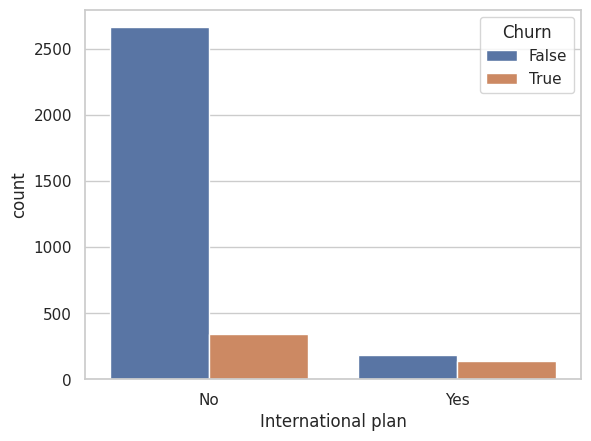

In [ ]:
sns.countplot(data=df, x='International plan', hue='Churn')
plt.show()

In [ ]:
print(df.select_dtypes(include='number').skew().sort_values(ascending=False))

Total intl calls          1.321478
Number vmail messages     1.264824
Area code                 1.126823
Customer service calls    1.091359
Account length            0.096606
Total night calls         0.032500
Total night minutes       0.008921
Total night charge        0.008886
Total eve charge         -0.023858
Total eve minutes        -0.023877
Total day minutes        -0.029077
Total day charge         -0.029083
Total charges            -0.034791
Total eve calls          -0.055563
Total day calls          -0.111787
Total intl minutes       -0.245136
Total intl charge        -0.245287
dtype: float64


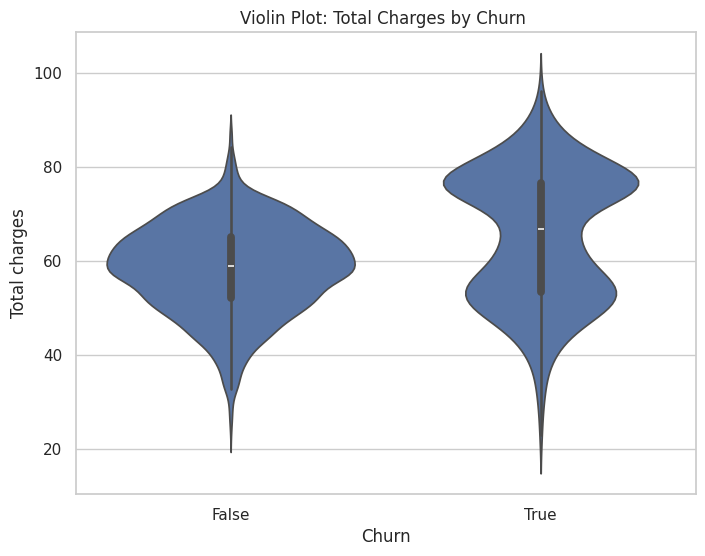

In [ ]:
fig, axes = plt.subplots(figsize=(8, 6))
sns.violinplot(data=df, x='Churn', y='Total charges', ax=axes)
axes.set_title('Violin Plot: Total Charges by Churn ')
plt.show()

In [ ]:
state_churn = df.groupby('State')['Churn'].mean().sort_values(ascending=False)
print(state_churn.head().round(3))

State
CA    0.265
NJ    0.265
TX    0.250
MD    0.243
SC    0.233
Name: Churn, dtype: float64


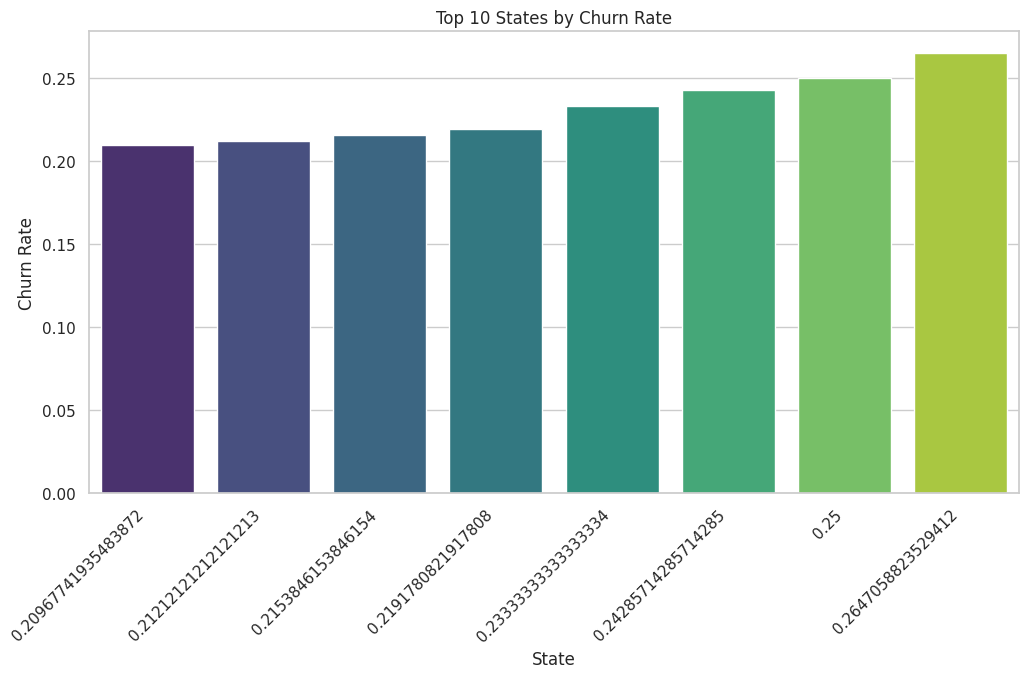

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=state_churn.head(10), y=state_churn.head(10).values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.xlabel('State')
plt.ylabel('Churn Rate')
plt.title('Top 10 States by Churn Rate')
plt.show()

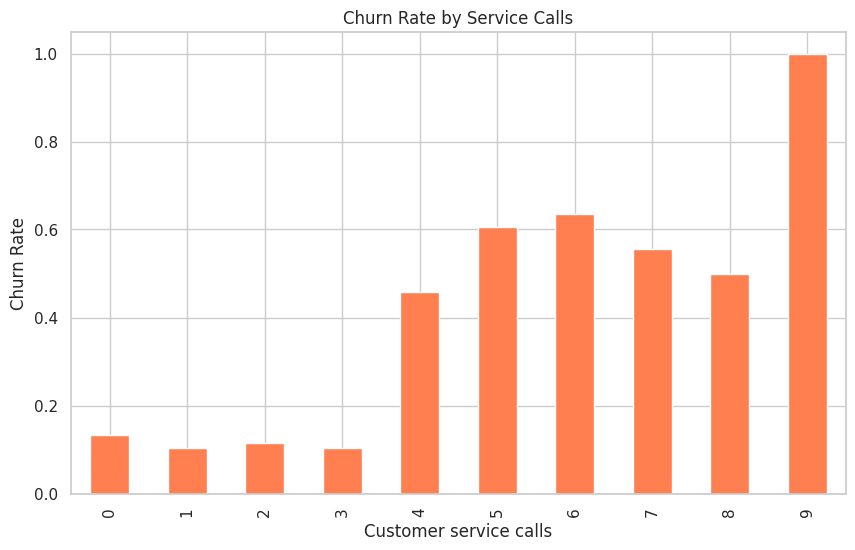

In [ ]:
#Churn Rate by Service Calls
churn_by_calls = (df.groupby("Customer service calls")["Churn"].mean())
fig, ax = plt.subplots(figsize=(10, 6))
churn_by_calls.plot(kind="bar", color='coral', ax=ax)
ax.set_title("Churn Rate by Service Calls")
ax.set_ylabel("Churn Rate")
plt.show()

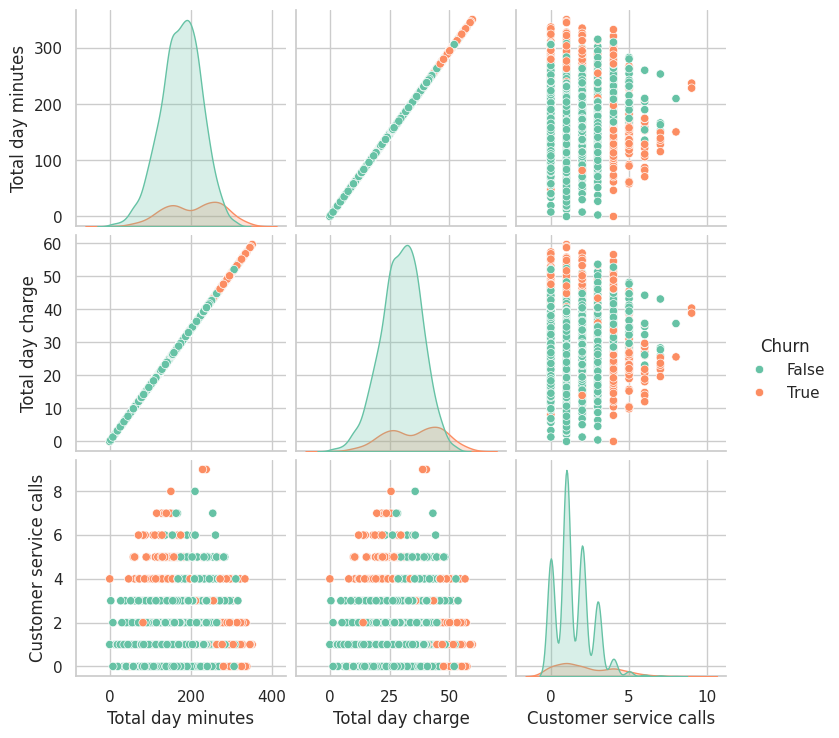

In [ ]:
sns.pairplot(
    df[[
        "Total day minutes",
        "Total day charge",
        "Customer service calls",
        "Churn"
    ]],
    hue="Churn",
    palette="Set2"
)

plt.show()

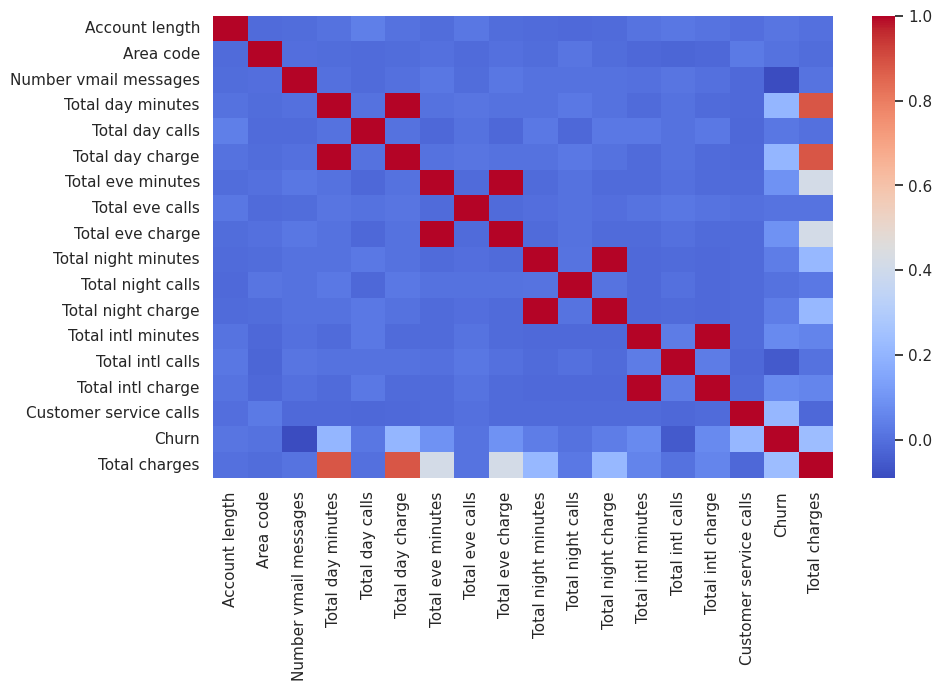

Churn,False,True
International plan,,
No,0.89,0.11
Yes,0.58,0.42


In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.show()
display(pd.crosstab(df['International plan'], df['Churn'], normalize='index').round(2))

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Applying IQR-based clipping to numerical columns:")
for col in numeric_cols:
    if col == 'Churn': # Skip the target variable if it's numerical (boolean converted to int)
        continue
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    initial_min = df[col].min()
    initial_max = df[col].max()
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    final_min = df[col].min()
    final_max = df[col].max()

    if initial_min != final_min or initial_max != final_max:
        print(f"  - Column '{col}': Outliers clipped. Min changed from {initial_min:.2f} to {final_min:.2f}, Max changed from {initial_max:.2f} to {final_max:.2f}")
    else:
        print(f"  - Column '{col}': No outliers found or already within bounds.")

Applying IQR-based clipping to numerical columns:
  - Column 'Account length': Outliers clipped. Min changed from 1.00 to 1.00, Max changed from 243.00 to 206.50
  - Column 'Area code': No outliers found or already within bounds.
  - Column 'Number vmail messages': Outliers clipped. Min changed from 0.00 to 0.00, Max changed from 51.00 to 50.00
  - Column 'Total day minutes': Outliers clipped. Min changed from 0.00 to 34.65, Max changed from 350.80 to 325.45
  - Column 'Total day calls': Outliers clipped. Min changed from 0.00 to 46.50, Max changed from 165.00 to 154.50
  - Column 'Total day charge': Outliers clipped. Min changed from 0.00 to 5.89, Max changed from 59.64 to 55.33
  - Column 'Total eve minutes': Outliers clipped. Min changed from 0.00 to 63.55, Max changed from 363.70 to 338.35
  - Column 'Total eve calls': Outliers clipped. Min changed from 0.00 to 46.50, Max changed from 170.00 to 154.50
  - Column 'Total eve charge': Outliers clipped. Min changed from 0.00 to 5.40, M

In [ ]:
df['Total_Usage'] = df['Total day minutes'] + df['Total eve minutes'] + df['Total night minutes'] + df['Total intl minutes']
df['Service_Stress'] = df['Customer service calls'] / (df['Account length'] + 1)

# Using pd.qcut as requested (Expert Review Addition)
df['Revenue_Segment'] = pd.qcut(df['Total charges'], q=3, labels=['Low', 'Medium', 'High'])

In [ ]:
print(df.columns)

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn', 'Total charges', 'Total_Usage', 'Service_Stress',
       'Revenue_Segment'],
      dtype='object')


In [ ]:
le = LabelEncoder()
df['International plan'] = le.fit_transform(df['International plan'])
df['Voice mail plan'] = le.fit_transform(df['Voice mail plan'])
df['Churn'] = le.fit_transform(df['Churn'])


In [ ]:
# Automated High Correlation Detection
corr_matrix = df.corr(numeric_only=True).abs()
high_corr = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr.add(corr_matrix.columns[i])

print(f"Dropping highly correlated data-driven columns: {high_corr}")
df.drop(columns=high_corr, inplace=True)

Dropping highly correlated data-driven columns: {'Number vmail messages', 'Total day charge', 'Total night charge', 'Total intl charge', 'Total eve charge'}


In [ ]:
area_churn = (
    df.groupby("Area code")["Churn"]
      .mean()
)

print(area_churn)

Area code
408    0.145585
415    0.142598
510    0.148810
Name: Churn, dtype: float64


In [ ]:
# Drop Area Code
df.drop('Area code', axis=1, inplace=True, errors='ignore')
print("Note: 'Area code' was dropped because it acts as an arbitrary ID and has no predictive power for churn.")

Note: 'Area code' was dropped because it acts as an arbitrary ID and has no predictive power for churn.


In [ ]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# Compare Scalers
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()

In [ ]:
for col in X_train.columns:
    try:
        X_train[col].astype(float)
    except:
        print(f"Problem column: {col}, sample values: {X_train[col].unique()[:5]}")

Problem column: State, sample values: ['ND' 'ME' 'PA' 'MS' 'DC']
Problem column: Revenue_Segment, sample values: ['High', 'Medium', 'Low']
Categories (3, object): ['Low' < 'Medium' < 'High']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [ ]:
# Revenue_Segment drop karo X_train/X_test se
X_train = X_train.drop(columns=['Revenue_Segment'], errors='ignore')
X_test = X_test.drop(columns=['Revenue_Segment'], errors='ignore')

# Ab scale karo
X_train_std = pd.DataFrame(scaler_std.fit_transform(X_train), columns=X_train.columns)
X_test_std = pd.DataFrame(scaler_std.transform(X_test), columns=X_test.columns)

In [ ]:
X_train_mm = pd.DataFrame(scaler_minmax.fit_transform(X_train), columns=X_train.columns)
X_train_rob = pd.DataFrame(scaler_robust.fit_transform(X_train), columns=X_train.columns)

In [ ]:
print("StandardScaler Mean:", X_train_std['Total day minutes'].mean().round(2))
print("MinMaxScaler Min-Max:", X_train_mm['Total day minutes'].min(), "-", X_train_mm['Total day minutes'].max())

StandardScaler Mean: -0.0
MinMaxScaler Min-Max: 0.0 - 1.0


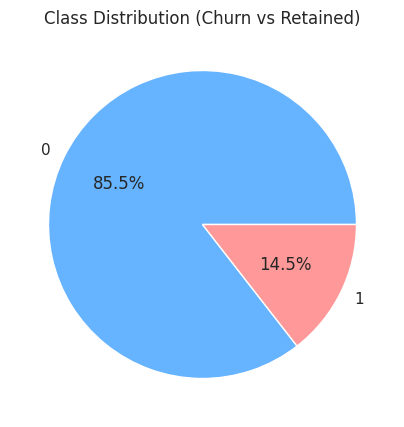

In [ ]:
# Visualizing Imbalance
plt.figure(figsize=(5,5))
y_train.value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title("Class Distribution (Churn vs Retained)")
plt.ylabel("")
plt.show()

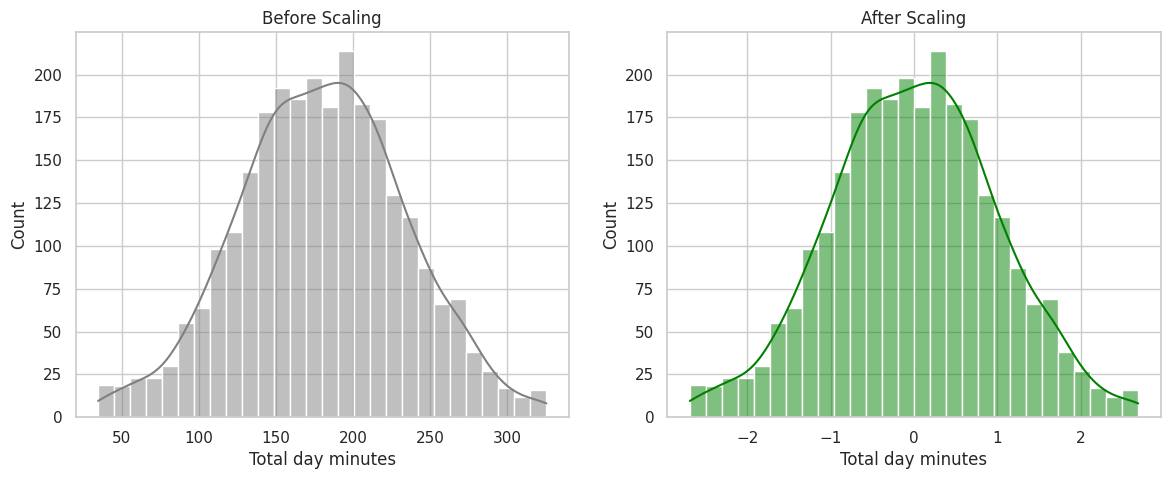

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(X_train["Total day minutes"], ax=axes[0], kde=True, color='gray').set_title("Before Scaling")
sns.histplot(X_train_std["Total day minutes"], ax=axes[1], kde=True, color='green').set_title("After Scaling")
plt.show()

In [ ]:
# Train Logistic & Decision Tree


lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_std, y_train)
pred_lr, prob_lr = lr.predict(X_test_std), lr.predict_proba(X_test_std)[:, 1]
print(f"Logistic Regression -> Recall: {recall_score(y_test, pred_lr):.3f}")

Logistic Regression -> Recall: 0.722


In [ ]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt.fit(X_train_std, y_train)
pred_dt, prob_dt = dt.predict(X_test_std), dt.predict_proba(X_test_std)[:, 1]
print(f"Decision Tree -> Recall: {recall_score(y_test, pred_dt):.3f}")

Decision Tree -> Recall: 0.887


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediction
pred_knn = knn.predict(X_test)

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Prediction
pred_nb = nb.predict(X_test)

In [ ]:
# Predictions

pred_lr = lr.predict(X_test)
pred_dt = dt.predict(X_test)
pred_rf = rf.predict(X_test)
pred_knn = knn.predict(X_test)
pred_nb = nb.predict(X_test)

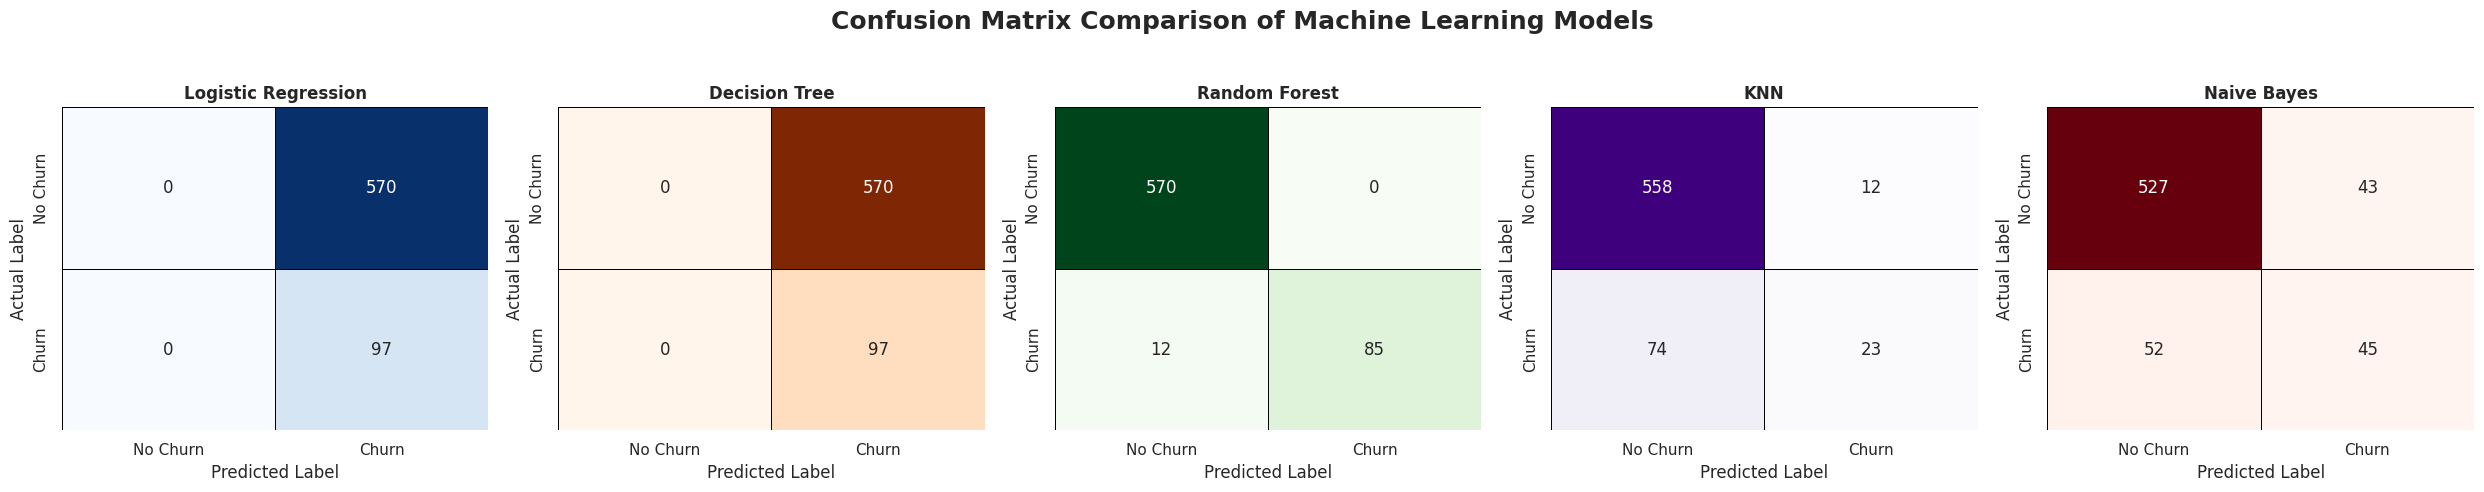

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

models = [
    ("Logistic Regression", pred_lr, "Blues"),
    ("Decision Tree", pred_dt, "Oranges"),
    ("Random Forest", pred_rf, "Greens"),
    ("KNN", pred_knn, "Purples"),
    ("Naive Bayes", pred_nb, "Reds")
]

for ax, (title, pred, color) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=color,
        cbar=False,
        linewidths=0.5,
        linecolor="black",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"],
        ax=ax
    )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.suptitle("Confusion Matrix Comparison of Machine Learning Models",
             fontsize=18, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Full Metrics Dashboard
def evaluate_model(y_true, y_pred, y_prob):
    ...

In [ ]:
# Full Metrics Dashboard
def evaluate_model(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob) if y_prob is not None else 0.5
    }

results = [
    evaluate_model(y_test, pred_lr, prob_lr),
    evaluate_model(y_test, pred_dt, prob_dt)
]
comp_df = pd.DataFrame(results, index=['Logistic Regression', 'Decision Tree']).round(3)
display(comp_df)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.145,0.145,1.0,0.254,0.804
Decision Tree,0.145,0.145,1.0,0.254,0.949


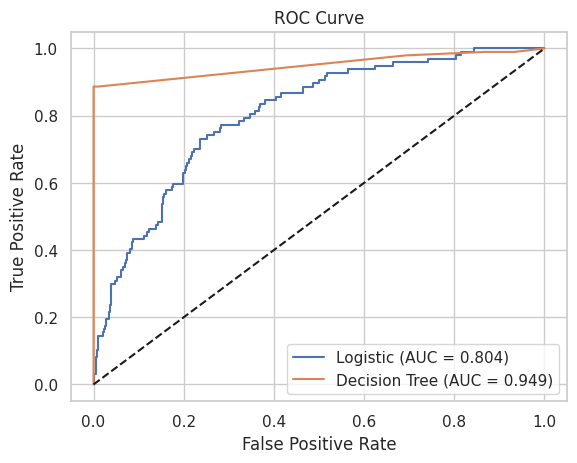

In [ ]:
# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, prob_dt)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic (AUC = {roc_auc_score(y_test, prob_lr):.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test, prob_dt):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

,Importance
Total charges,0.396759
International plan,0.245506
Customer service calls,0.185102
Total intl minutes,0.090469
Voice mail plan,0.036912


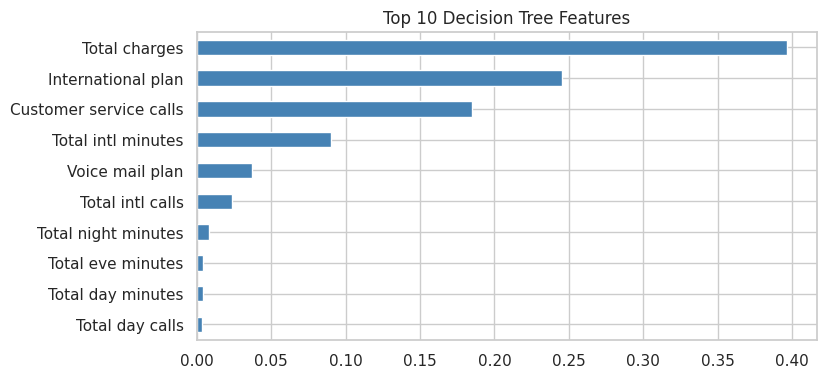

In [ ]:
# Feature Importance Table & Chart
feat_imp = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
display(pd.DataFrame(feat_imp, columns=['Importance']).head(5)) # Added table
feat_imp.head(10).plot(kind='barh', figsize=(8,4), color='steelblue').invert_yaxis()
plt.title('Top 10 Decision Tree Features')
plt.show()


In [ ]:
# Model Persistence
joblib.dump(dt, 'churn_model.pkl')
joblib.dump(scaler_std, 'scaler.pkl')

['scaler.pkl']

In [ ]:
#Persistence & Mock Production Test
#In industry, training a model is only step one.
#Saving the artifacts and proving they can predict on unseen data is how you pass an ML Ops interview

# Save Artifacts
joblib.dump(dt, 'churn_model.pkl')
joblib.dump(scaler_std, 'scaler.pkl')
print("Model and Scaler exported to .pkl successfully.")

# Mock Deployment Prediction (Expert Review Addition)
print("Testing Pipeline on New Customer")
loaded_model = joblib.load('churn_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Simulating the first customer in the test set arriving via API
new_customer_data = X_test.iloc[0]
# Reshape the 1D Series to a 2D array as expected by the scaler's transform method
new_customer_scaled = loaded_scaler.transform(new_customer_data.values.reshape(1, -1))
prediction = loaded_model.predict(new_customer_scaled)

print(f"Customer Data loaded. Predicted Churn Status: {'Will Churn' if prediction == 1 else 'Will Retain'}")

Model and Scaler exported to .pkl successfully.
Testing Pipeline on New Customer
Customer Data loaded. Predicted Churn Status: Will Churn


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
lr = LogisticRegression(max_iter=1000)

dt = DecisionTreeClassifier(random_state=42)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

knn = KNeighborsClassifier(
    n_neighbors=5
)

nb = GaussianNB()

In [ ]:
X_train_std = pd.DataFrame(
    scaler_std.fit_transform(X_train),
    columns=X_train.columns
)

X_test_std = pd.DataFrame(
    scaler_std.transform(X_test),
    columns=X_test.columns
)

In [ ]:
#Logistic Regression
lr.fit(X_train_std, y_train)
lr_pred = lr.predict(X_test_std)

In [ ]:
#KNN
knn.fit(X_train_std, y_train)
knn_pred = knn.predict(X_test_std)

In [ ]:
#Naive bayes
nb.fit(X_train_std, y_train)
nb_pred = nb.predict(X_test_std)

In [ ]:
# Random Forest
dt.fit(X_train, y_train)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#Decision Tree
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Naive Bayes"
    ],

    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_nb)
    ],

    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_dt),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_knn),
        precision_score(y_test, pred_nb)
    ],

    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_dt),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_knn),
        recall_score(y_test, pred_nb)
    ],

    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_dt),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_knn),
        f1_score(y_test, pred_nb)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.145427   0.145427  1.000000  0.253927
1        Decision Tree  0.145427   0.145427  1.000000  0.253927
2        Random Forest  0.982009   1.000000  0.876289  0.934066
3                  KNN  0.871064   0.657143  0.237113  0.348485
4          Naive Bayes  0.857571   0.511364  0.463918  0.486486


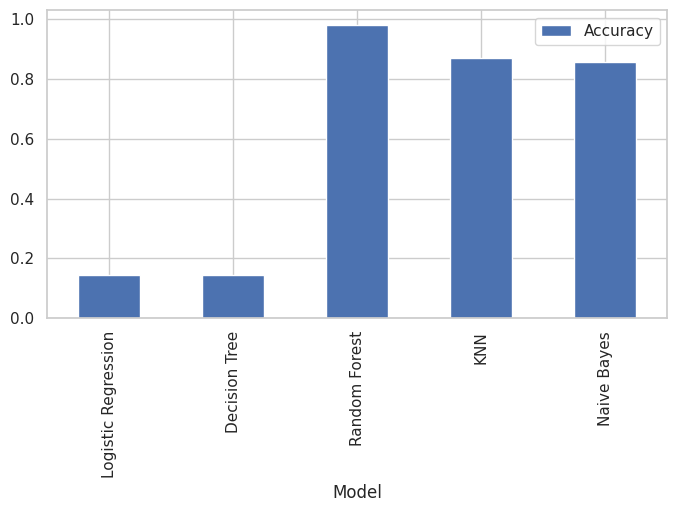

In [ ]:
results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(8,4)
)

plt.show()

In [ ]:
pred_lr = lr.predict(X_test)
pred_dt = dt.predict(X_test)
pred_rf = rf.predict(X_test)
pred_knn = knn.predict(X_test)
pred_nb = nb.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "KNN": pred_knn,
    "Naive Bayes": pred_nb
}

for name, pred in models.items():
    print("=" * 50)
    print(name)
    print("=" * 50)
    print(classification_report(y_test, pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       570
           1       0.15      1.00      0.25        97

    accuracy                           0.15       667
   macro avg       0.07      0.50      0.13       667
weighted avg       0.02      0.15      0.04       667

Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       570
           1       0.81      0.89      0.85        97

    accuracy                           0.95       667
   macro avg       0.90      0.93      0.91       667
weighted avg       0.96      0.95      0.95       667

Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       570
           1       1.00      0.88      0.93        97

    accuracy                           0.98       667
   macro avg       0.99      0.94      0.96       667
weighted avg       0.98   

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

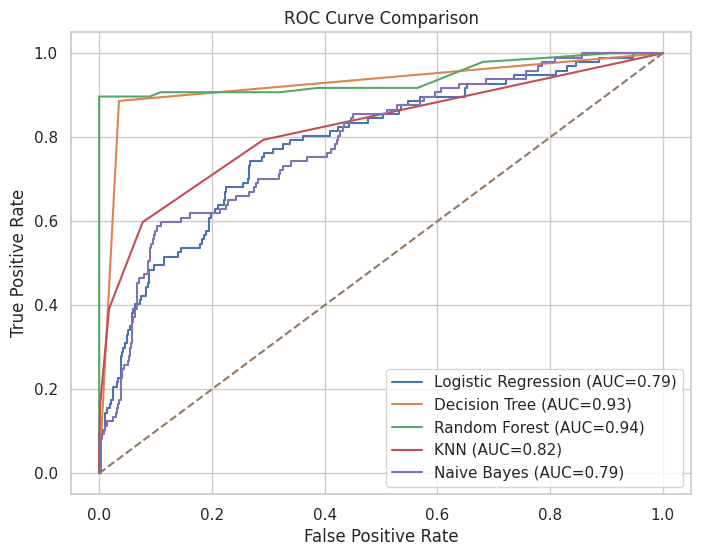

In [ ]:
# Probability predictions
lr_prob = lr.predict_proba(X_test_std)[:,1]

dt_prob = dt.predict_proba(X_test)[:,1]

rf_prob = rf.predict_proba(X_test)[:,1]

knn_prob = knn.predict_proba(X_test_std)[:,1]

nb_prob = nb.predict_proba(X_test_std)[:,1]


models_prob = {
    "Logistic Regression": lr_prob,
    "Decision Tree": dt_prob,
    "Random Forest": rf_prob,
    "KNN": knn_prob,
    "Naive Bayes": nb_prob
}


plt.figure(figsize=(8,6))


for name, prob in models_prob.items():

    fpr, tpr, _ = roc_curve(y_test, prob)

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.2f})"
    )


plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

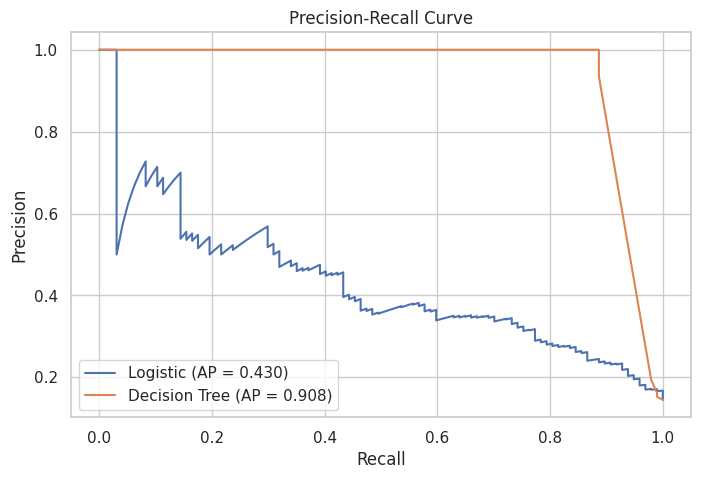

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Precision-Recall values
precision_lr, recall_lr, _ = precision_recall_curve(y_test, prob_lr)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, prob_dt)

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    recall_lr,
    precision_lr,
    label=f"Logistic (AP = {average_precision_score(y_test, prob_lr):.3f})"
)

plt.plot(
    recall_dt,
    precision_dt,
    label=f"Decision Tree (AP = {average_precision_score(y_test, prob_dt):.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Probability scores for ROC-AUC

prob_lr = lr.predict_proba(X_test)[:, 1]
prob_dt = dt.predict_proba(X_test)[:, 1]
prob_rf = rf.predict_proba(X_test)[:, 1]
prob_knn = knn.predict_proba(X_test)[:, 1]
prob_nb = nb.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Naive Bayes"
    ],

    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_nb)
    ],

    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_dt),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_knn),
        precision_score(y_test, pred_nb)
    ],

    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_dt),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_knn),
        recall_score(y_test, pred_nb)
    ],

    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_dt),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_knn),
        f1_score(y_test, pred_nb)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, prob_lr),
        roc_auc_score(y_test, prob_dt),
        roc_auc_score(y_test, prob_rf),
        roc_auc_score(y_test, prob_knn),
        roc_auc_score(y_test, prob_nb)
    ]
})

print(comparison.round(3))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     0.145      0.145   1.000     0.254    0.500
1        Decision Tree     0.954      0.811   0.887     0.847    0.926
2        Random Forest     0.982      1.000   0.876     0.934    0.940
3                  KNN     0.145      0.145   1.000     0.254    0.525
4          Naive Bayes     0.145      0.145   1.000     0.254    0.500


,Importance
Total charges,0.254487
Total day minutes,0.093602
Customer service calls,0.092273
International plan,0.085702
Total_Usage,0.082263
Voice mail plan,0.070400
Total intl minutes,0.054151
Total intl calls,0.051849
Total eve minutes,0.033011
Total night minutes,0.031162


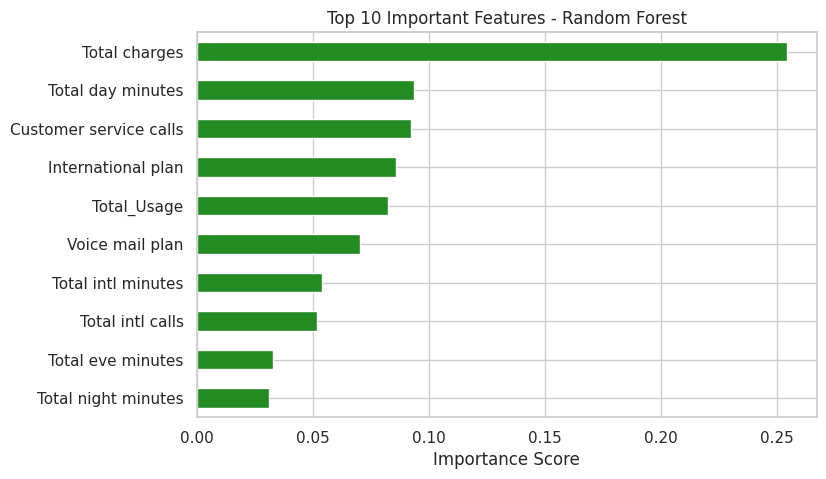

In [ ]:
# Feature Importance - Random Forest
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
display(
    pd.DataFrame(feature_importance, columns=["Importance"]).head(10)
)
plt.figure(figsize=(8,5))
feature_importance.head(10).plot(
    kind="barh",
    color="forestgreen"
)
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
model_selection = comparison.copy()

model_selection = model_selection.sort_values(
    by="Recall",
    ascending=False
)

display(model_selection)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.145427,0.145427,1.000000,0.253927,0.500000
4,Naive Bayes,0.145427,0.145427,1.000000,0.253927,0.500000
3,KNN,0.145427,0.145427,1.000000,0.253927,0.525393
1,Decision Tree,0.953523,0.811321,0.886598,0.847291,0.925755
2,Random Forest,0.982009,1.000000,0.876289,0.934066,0.940378


In [ ]:
best_model_name = model_selection.iloc[0]["Model"]

print(f"Selected Model for Deployment : {best_model_name}")

Selected Model for Deployment : Logistic Regression


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Baseline Decision Tree
baseline_dt = DecisionTreeClassifier(random_state=42)

baseline_dt.fit(X_train, y_train)

baseline_pred = baseline_dt.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Baseline Accuracy : {baseline_accuracy:.4f}")

Baseline Accuracy : 0.9535


In [ ]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"]
}

param_grid

{'criterion': ['gini', 'entropy'],
 'max_depth': [3, 5, 10, 15, None],
 'min_samples_split': [2, 5, 10],
 'min_samples_leaf': [1, 2, 4],
 'max_features': [None, 'sqrt', 'log2']}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
print("Best Parameters")
print(grid_search.best_params_)

print("\nBest Cross Validation Score")
print(round(grid_search.best_score_,4))

Best Parameters
{'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10}

Best Cross Validation Score
0.9749


In [ ]:
#Tuned Decision Tree
best_dt = grid_search.best_estimator_
pred_tuned = best_dt.predict(X_test)
tuned_accuracy = accuracy_score(y_test, pred_tuned)

print("Test Accuracy :", round(tuned_accuracy,4))

Test Accuracy : 0.982


In [ ]:
tuning_comparison = pd.DataFrame({

    "Model":[
        "Baseline Decision Tree",
        "Tuned Decision Tree"
    ],

    "Accuracy":[
        baseline_accuracy,
        tuned_accuracy
    ]
})

tuning_comparison

,Model,Accuracy
0,Baseline Decision Tree,0.953523
1,Tuned Decision Tree,0.982009


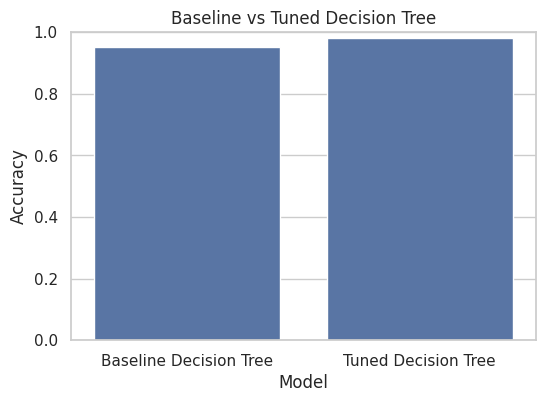

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=tuning_comparison,
    x="Model",
    y="Accuracy"
)
plt.title("Baseline vs Tuned Decision Tree")
plt.ylim(0,1)
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 10, 15, None],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10]},
                   random_state=42, scoring='accuracy')

In [ ]:
print("Best Parameters")
print(random_search.best_params_)

print("\nBest Cross Validation Score")
print(round(random_search.best_score_,4))

Best Parameters
{'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 5, 'criterion': 'gini'}

Best Cross Validation Score
0.9737


In [ ]:
best_random_dt = random_search.best_estimator_
pred_random = best_random_dt.predict(X_test)
random_accuracy = accuracy_score(y_test, pred_random)

print("Random Search Test Accuracy :", round(random_accuracy,4))

Random Search Test Accuracy : 0.9835


In [ ]:
search_comparison = pd.DataFrame({

    "Model":[
        "Baseline DT",
        "Grid Search DT",
        "Random Search DT"
    ],

    "Accuracy":[
        baseline_accuracy,
        tuned_accuracy,
        random_accuracy
    ]
})

search_comparison

,Model,Accuracy
0,Baseline DT,0.953523
1,Grid Search DT,0.982009
2,Random Search DT,0.983508


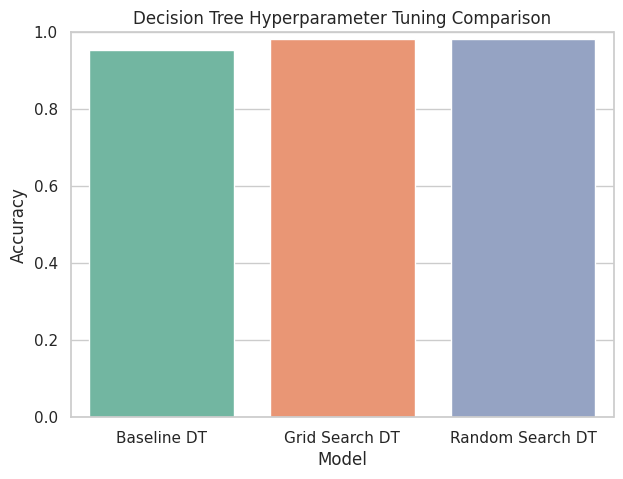

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=search_comparison,
    x="Model",
    y="Accuracy",
    palette="Set2"
)

plt.title("Decision Tree Hyperparameter Tuning Comparison")
plt.ylim(0,1)
plt.show()

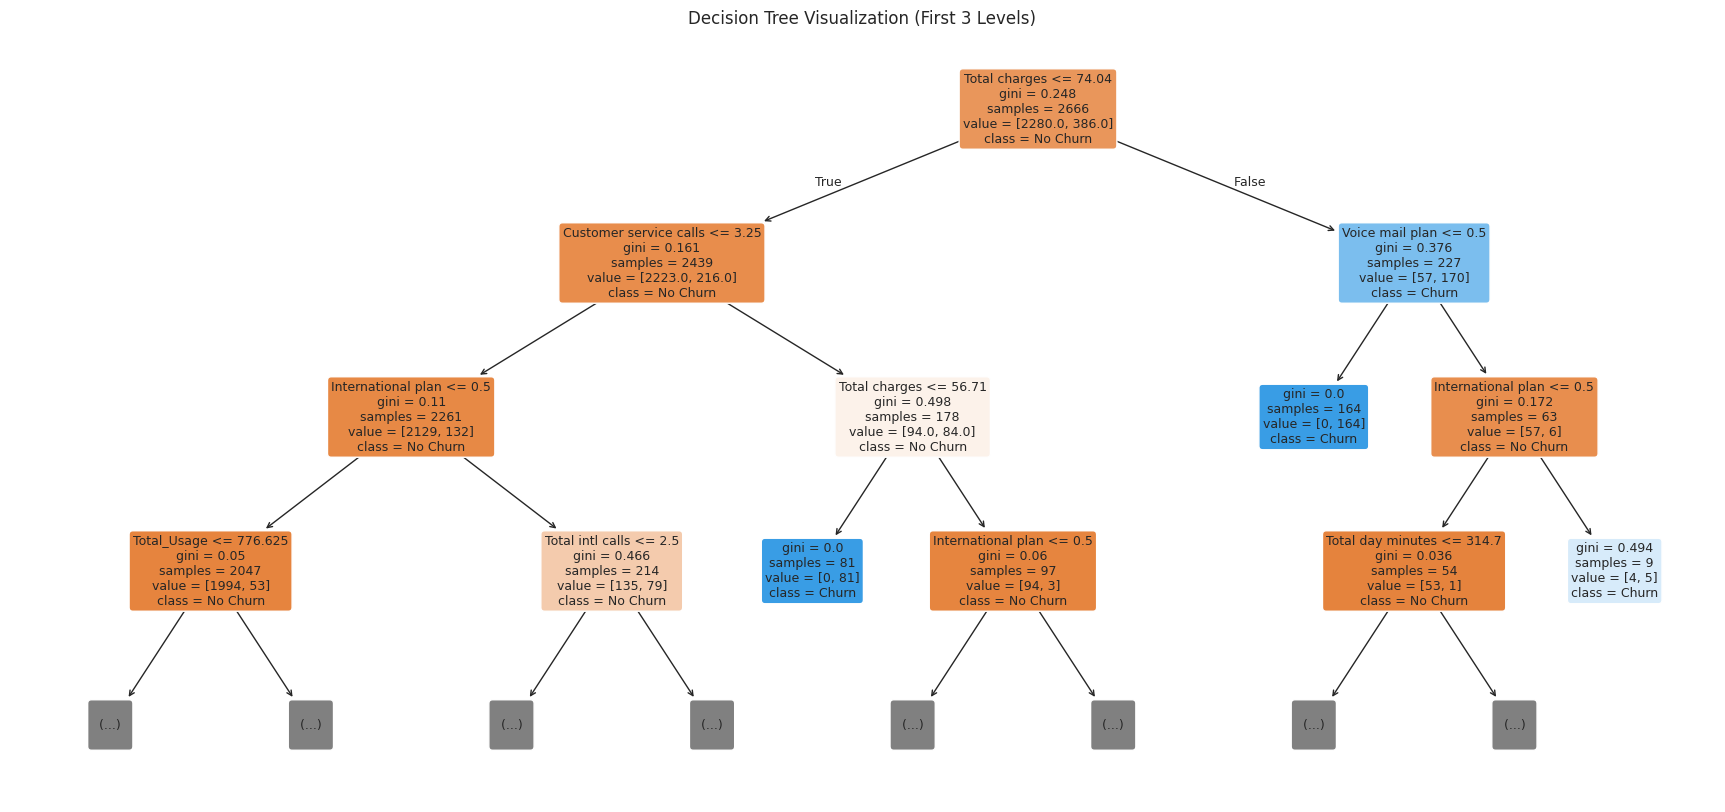

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22,10))

plot_tree(
    best_dt,
    feature_names=X_train.columns,
    class_names=["No Churn","Churn"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree Visualization (First 3 Levels)")
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", DecisionTreeClassifier(**grid_search.best_params_, random_state=42))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, min_samples_leaf=2,
                                        min_samples_split=10,
                                        random_state=42))])

In [ ]:
joblib.dump(pipeline, "best_model.pkl")
print("Pipeline saved successfully.")

Pipeline saved successfully.


In [ ]:
loaded_pipeline = joblib.load("best_model.pkl")
print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [ ]:
sample_customer = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(sample_customer)
probability = loaded_pipeline.predict_proba(sample_customer)

print("Prediction :", prediction[0])
print("Prediction Probabilities :", probability)

Prediction : 1
Prediction Probabilities : [[0. 1.]]


In [ ]:
sample_customer = X_test.iloc[[0]]

display(sample_customer)

prediction = loaded_pipeline.predict(sample_customer)

if prediction[0] == 1:
    print("⚠️ Customer is likely to Churn")
else:
    print("✅ Customer is likely to Stay")

,State,Account length,International plan,Voice mail plan,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Total charges,Total_Usage,Service_Stress
717,49,161.0,0,0,191.9,113.0,70.9,87.0,204.8,107,13.4,4.0,3.5,51.49,481.0,0.021605


⚠️ Customer is likely to Churn
